Decision Tree Accuracy: 0.7877094972067039
Random Forest Accuracy: 0.8268156424581006

Comparison
Decision Tree : 0.7877094972067039
Random Forest : 0.8268156424581006


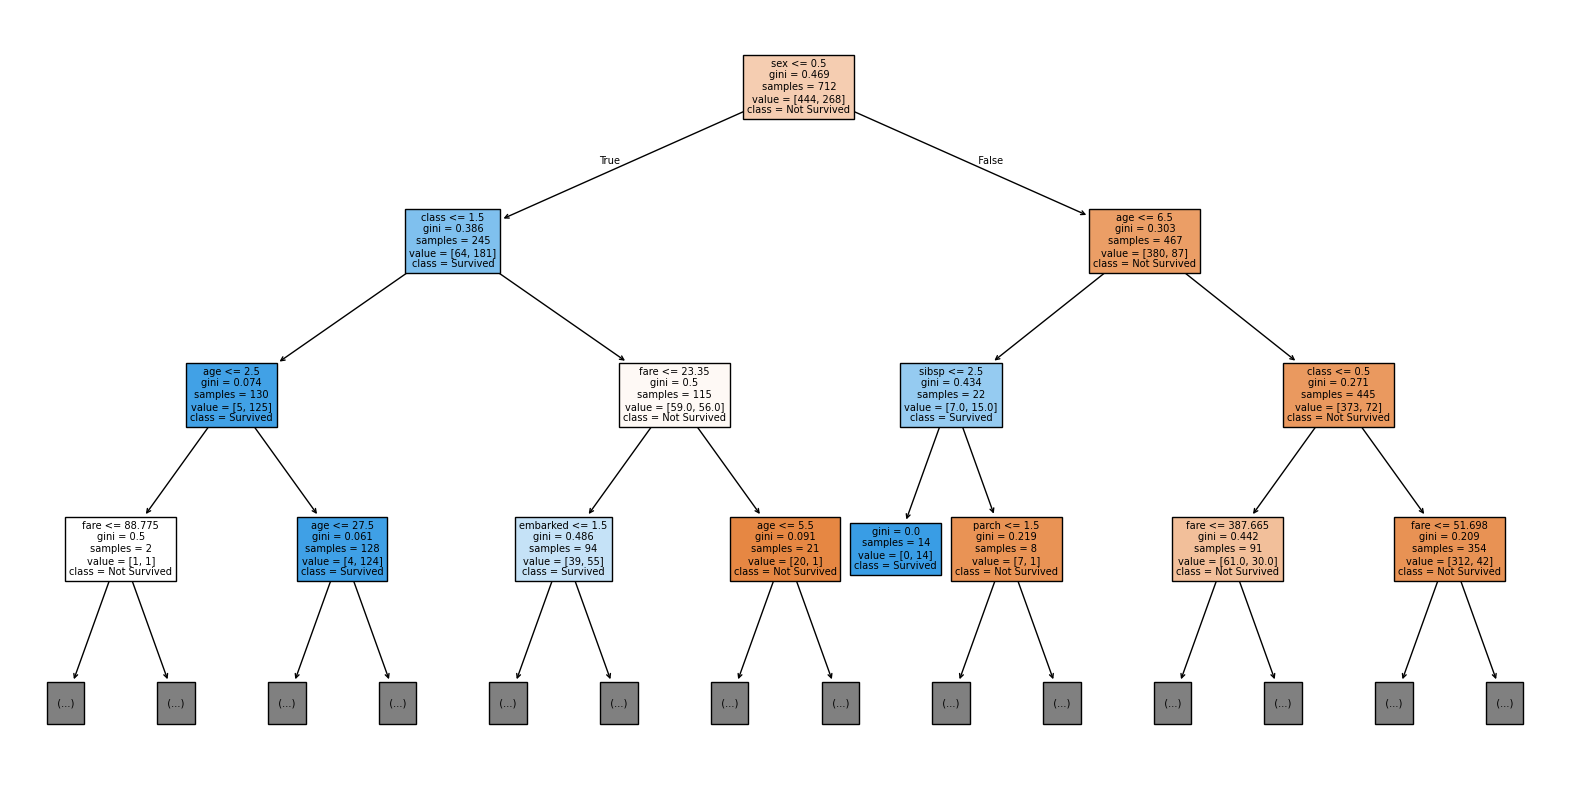

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# Load dataset
df = pd.read_csv("Titanic.csv")


# Handle missing values
df["age"] = df["age"].fillna(df["age"].mean())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])


# Convert categorical values into numbers
le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["embarked"] = le.fit_transform(df["embarked"])
df["class"] = le.fit_transform(df["class"])
df["who"] = le.fit_transform(df["who"])
df["alone"] = df["alone"].astype(int)


# Input and output
X = df.drop("survived", axis=1)
y = df["survived"]


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Decision Tree
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)


# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)


# Compare
print("\nComparison")
print("Decision Tree :", dt_accuracy)
print("Random Forest :", rf_accuracy)


# Display Decision Tree
plt.figure(figsize=(20, 10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    max_depth=3
)

plt.show()